In [ ]:
import sys
from pathlib import Path
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import ModelConfig, DEFAULT_CONFIG, BATCH_SIZE, NUM_WORKERS
from model import ADModel
from dataset import create_dataloaders
from data_split import create_train_val_split
from visualization import plot_training_curves

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <3F789787-FE38-3CE7-8599-064BDD0416EE> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torchvision/image.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/lib/libtorch_cpu.dylib
  warn(f"Failed to load image Python extension: {e}")


## Configuration Parameters


In [ ]:
DATASET_NAME = "Pitt"

In [ ]:
# ========== Path Configuration ==========
PROJECT_ROOT = script_dir.parent.parent.parent
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemap-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemap-val.csv"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{DATASET_NAME}_merged"
MODEL_OUTPUT_DIR = PROJECT_ROOT / f"models/{DATASET_NAME}_egemap_multi_seed"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EGEMAP_FEATURE_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_egemap_features"

# ========== Training Parameters ==========
MAX_EPOCHS = 50
LEARNING_RATE = 3e-3
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-2
NUM_WORKERS = 4
TRAIN_RATIO = 0.8
RANDOM_SEEDS = [21, 42, 84, 168, 336]
DATA_SPLIT_SEED = 42

## Step 1: Create Train/Val Split for Address Dataset


In [ ]:
# Use the create_train_val_split function with eGeMAPS mode
TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir=RAW_AUDIO_DIR,
    train_csv_path=TRAIN_CSV,
    val_csv_path=VAL_CSV,
    feature_dir_name=EGEMAP_FEATURE_DIR,
    train_ratio=TRAIN_RATIO,
    random_seed=DATA_SPLIT_SEED,
    dataset_name=DATASET_NAME,
    xlsr=False  # eGeMAPS mode
)


============= Pitt Train/Val Split Complete! =============
训练集: 4494 样本 (Control: 2021, Dementia: 2473)
验证集: 1125 样本 (Control: 506, Dementia: 619)

训练集CSV 路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Pitt-egemap-train.csv
验证集CSV 路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Pitt-egemap-val.csv


## Step 2: 自动提取 eGeMAPS 特征


In [ ]:
# 自动提取特征
import sys
from pathlib import Path

# extract_features.py 现在在同一目录下，直接导入
from extract_egemap_feature import extract_features_from_csv

print("=" * 60)
print("开始提取 eGeMAPS 特征...")
print("=" * 60)
print()

# 提取训练集特征
if TRAIN_CSV.exists():
    print(f"========提取训练集特征=========")
    print(f"CSV 路径: {TRAIN_CSV}")
    extract_features_from_csv(TRAIN_CSV, dataset_name = DATASET_NAME)
else:
    print(f"⚠️  训练集 CSV 不存在: {TRAIN_CSV}")
    print()

# 提取验证集特征
if VAL_CSV.exists():
    print(f"========提取验证集特征=========")
    print(f"CSV 路径: {VAL_CSV}")
    extract_features_from_csv(VAL_CSV, dataset_name = DATASET_NAME)
else:
    print(f"⚠️  验证集 CSV 不存在: {VAL_CSV}")
    print()


2025-11-20 23:48:36 | INFO | numexpr.utils | NumExpr defaulting to 12 threads.
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


开始提取 eGeMAPS 特征...

========提取训练集特征=========
CSV 路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Pitt-egemap-train.csv
共 4494 个音频文件



提取中: 100%|██████████| 4494/4494 [03:48<00:00, 19.69it/s]



============= 提取完成！ =============
成功提取: 4421 个
已存在跳过: 73 个
总计: 4494 个
========提取验证集特征=========
CSV 路径: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Pitt-egemap-val.csv
共 1125 个音频文件



提取中: 100%|██████████| 1125/1125 [00:54<00:00, 20.49it/s]


============= 提取完成！ =============
成功提取: 1125 个
已存在跳过: 0 个
总计: 1125 个


## Step 3: Create Data Loaders


In [ ]:
# Create data loaders
train_loader, val_loader = create_dataloaders(
    TRAIN_CSV, VAL_CSV, PROJECT_ROOT, 
    BATCH_SIZE, NUM_WORKERS
)

all_results = {'seeds': [], 'val_accs': [], 'val_losses': []}

=============创建训练集（eGeMAPS 特征）=============
⚠️  特征包含 NaN/Inf，跳过: 035-0_000
⚠️  特征包含 NaN/Inf，跳过: 279-1_007
⚠️  特征包含 NaN/Inf，跳过: 468-0_009
⚠️  特征包含 NaN/Inf，跳过: 071-0_008
⚠️  特征包含 NaN/Inf，跳过: 257-0_015
⚠️  特征包含 NaN/Inf，跳过: 218-1_012
⚠️  特征包含 NaN/Inf，跳过: 017-4_004
⚠️  特征包含 NaN/Inf，跳过: 242-2_018
⚠️  特征包含 NaN/Inf，跳过: 010-1_000
⚠️  特征包含 NaN/Inf，跳过: 057-2_008
✅ 加载完成: 4484 个样本
   Control: 2018, Dementia: 2466

=============创建验证集（eGeMAPS 特征）=============
⚠️  特征包含 NaN/Inf，跳过: 076-2_002
⚠️  特征包含 NaN/Inf，跳过: 573-0_011
⚠️  特征包含 NaN/Inf，跳过: 336-1_002
✅ 加载完成: 1122 个样本
   Control: 505, Dementia: 617



## Step 4: Define Training Function and Model

In [ ]:
class MetricsCallback(pl.Callback):
    def __init__(self):
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = []
    
    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(trainer.callback_metrics.get('train_loss', 0).item())
        self.train_acc.append(trainer.callback_metrics.get('train_acc', 0).item())
    
    def on_validation_end(self, trainer, pl_module):
        if not trainer.sanity_checking:
            self.epochs.append(trainer.current_epoch)
            self.val_loss.append(trainer.callback_metrics.get('val_loss', 0).item())
            self.val_acc.append(trainer.callback_metrics.get('val_acc', 0).item())

class ADClassifier(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = ADModel(DEFAULT_CONFIG)
        self.save_hyperparameters()
    def forward(self, x):
        return self.model(x)
    def training_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def validation_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, labels)
        acc = (torch.argmax(logits, dim=1) == labels).float().mean()
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_epoch=True, prog_bar=True)
        return loss
    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def train_and_plot(seed, output_dir):
    """Train single seed and visualize"""
    pl.seed_everything(seed)
    seed_dir = output_dir / f"seed_{seed}"
    seed_dir.mkdir(exist_ok=True)
    
    model = ADClassifier()
    metrics_cb = MetricsCallback()
    callbacks = [
        ModelCheckpoint(dirpath=seed_dir, filename='best', monitor='val_acc', mode='max', save_top_k=1),
        EarlyStopping(monitor='val_acc', patience=10, mode='max'),
        metrics_cb
    ]
    
    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
    trainer_kwargs = {'max_epochs': MAX_EPOCHS, 'callbacks': callbacks, 'accelerator': accelerator,
                     'enable_progress_bar': True, 'enable_model_summary': False}
    if accelerator == 'gpu':
        trainer_kwargs['devices'] = 1
    trainer = pl.Trainer(**trainer_kwargs)
    
    trainer.fit(model, train_loader, val_loader)
    
    # Plot training curves using the visualization module
    plot_training_curves(
        epochs=metrics_cb.epochs,
        train_loss=metrics_cb.train_loss,
        val_loss=metrics_cb.val_loss,
        train_acc=metrics_cb.train_acc,
        val_acc=metrics_cb.val_acc,
        train_color='#2E86AB',
        val_color='#A23B72',
        title_prefix=f'Seed {seed}'
    )

    best_val_acc_val = max(metrics_cb.val_acc)
    best_val_loss = min(metrics_cb.val_loss)
    print(f" Seed {seed} : Val Acc = {best_val_acc_val*100:.2f}%, Val Loss = {best_val_loss:.4f}")
    
    return seed, best_val_acc_val, best_val_loss

### 1st Random Seed = 21

Seed set to 21
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/Pitt_egemap_multi_seed/seed_21 exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 15: 100%|██████████| 141/141 [00:00<00:00, 360.08it/s, v_num=104, train_loss_step=0.729, train_acc_step=0.500, val_loss=0.690, val_acc=0.554, train_loss_epoch=0.678, train_acc_epoch=0.560]


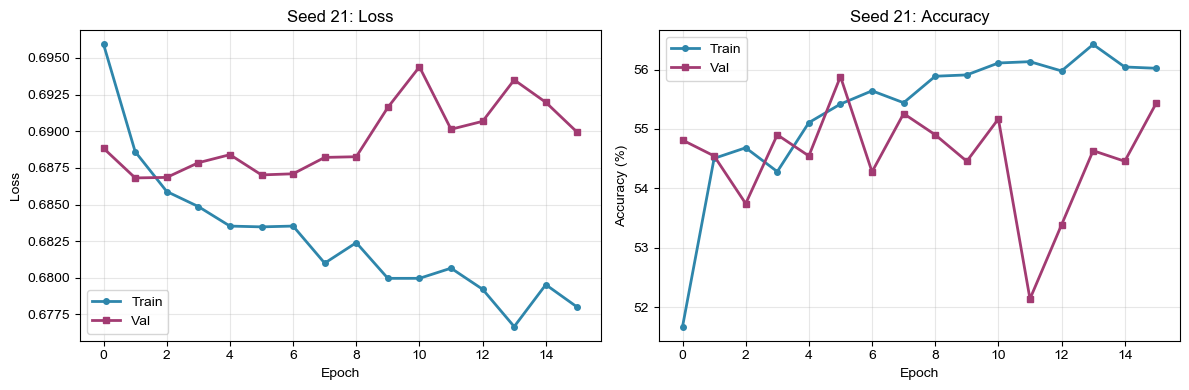

 Seed 21 : Val Acc = 55.88%, Val Loss = 0.6868


In [ ]:
# Train Seed 21
seed, val_acc, val_loss = train_and_plot(21, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 2nd Random Seed = 42

Seed set to 42
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/Pitt_egemap_multi_seed/seed_42 exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 10: 100%|██████████| 141/141 [00:00<00:00, 352.51it/s, v_num=105, train_loss_step=0.590, train_acc_step=0.750, val_loss=0.690, val_acc=0.532, train_loss_epoch=0.681, train_acc_epoch=0.562]


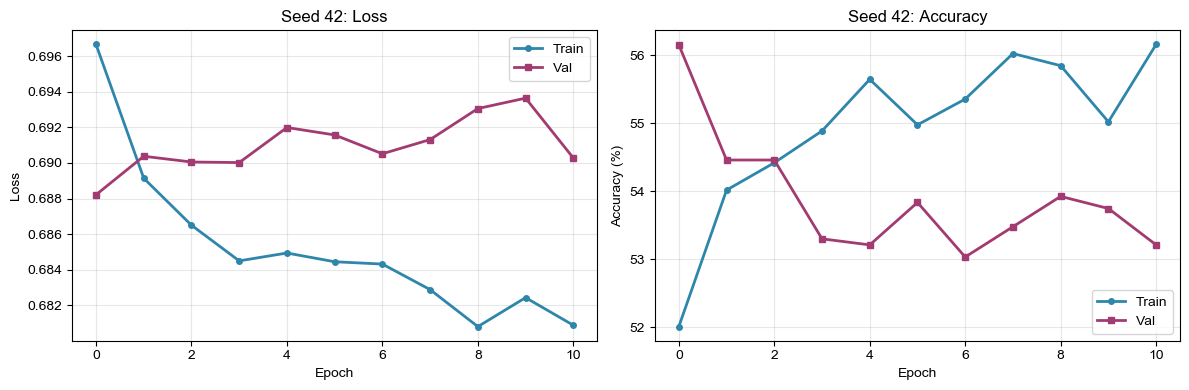

 Seed 42 : Val Acc = 56.15%, Val Loss = 0.6882


In [ ]:
# Train Seed 42
seed, val_acc, val_loss = train_and_plot(42, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 3rd Random Seed = 84

Seed set to 84
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/Pitt_egemap_multi_seed/seed_84 exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 17: 100%|██████████| 141/141 [00:00<00:00, 360.23it/s, v_num=106, train_loss_step=0.622, train_acc_step=0.750, val_loss=0.700, val_acc=0.514, train_loss_epoch=0.677, train_acc_epoch=0.564]


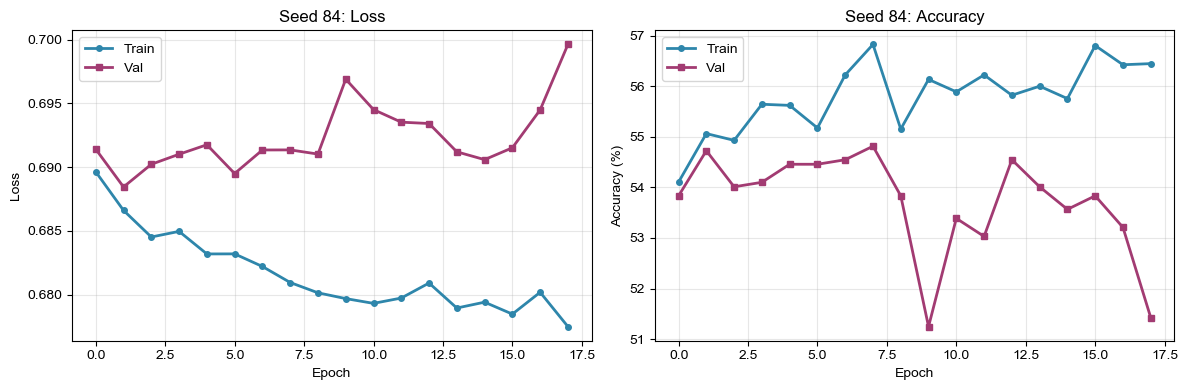

 Seed 84 : Val Acc = 54.81%, Val Loss = 0.6884


In [ ]:
# Train Seed 84
seed, val_acc, val_loss = train_and_plot(84, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 4th Random Seed = 168

Seed set to 168
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/Pitt_egemap_multi_seed/seed_168 exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 13: 100%|██████████| 141/141 [00:00<00:00, 349.20it/s, v_num=107, train_loss_step=0.670, train_acc_step=0.750, val_loss=0.689, val_acc=0.529, train_loss_epoch=0.679, train_acc_epoch=0.560]


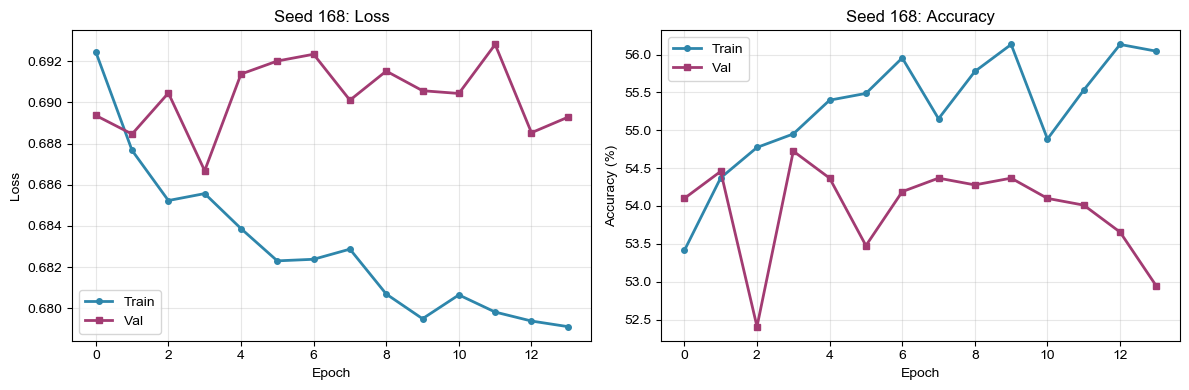

 Seed 168 : Val Acc = 54.72%, Val Loss = 0.6867


In [ ]:
# Train Seed 168
seed, val_acc, val_loss = train_and_plot(168, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


### 5th Random Seed = 336

Seed set to 336
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/pytorch_lightning/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 26: 100%|██████████| 141/141 [00:00<00:00, 347.28it/s, v_num=108, train_loss_step=0.736, train_acc_step=0.500, val_loss=0.692, val_acc=0.532, train_loss_epoch=0.675, train_acc_epoch=0.566]


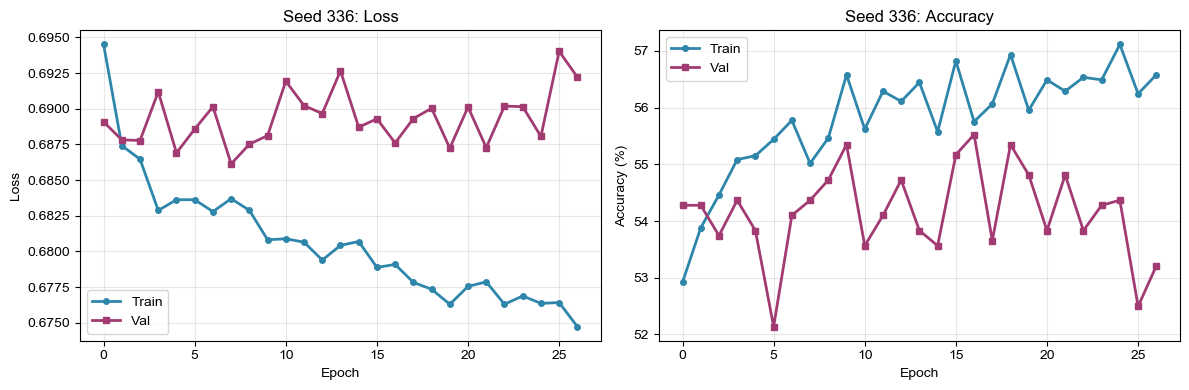

 Seed 336 : Val Acc = 55.53%, Val Loss = 0.6861


In [ ]:
# Train Seed 336
seed, val_acc, val_loss = train_and_plot(336, MODEL_OUTPUT_DIR)
all_results['seeds'].append(seed)
all_results['val_accs'].append(val_acc)
all_results['val_losses'].append(val_loss)


In [ ]:
# Compare all models
import numpy as np

seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']

# Calculate statistics
mean_acc = np.mean(val_accs)
mean_loss = np.mean(val_losses)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f}")
print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"  Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}")


Mean Validation Accuracy: 55.42%
Mean Validation Loss: 0.6873

Detailed Results:
  Seed 21: Acc=55.88%, Loss=0.6868
  Seed 42: Acc=56.15%, Loss=0.6882
  Seed 84: Acc=54.81%, Loss=0.6884
  Seed 168: Acc=54.72%, Loss=0.6867
  Seed 336: Acc=55.53%, Loss=0.6861
